# STAT 650 — Midterm Exam Report

**Author:** Sharvari Mhatre
**Date:** March 2026

---

## 1. Introduction

### 1.1 Dataset Overview

This report analyzes the **Restaurant & Consumer** dataset, which captures information about restaurants in Mexico, the consumers who visit them, and the ratings those consumers have provided. The data is distributed across **nine CSV files** organized into three categories:

| Category | Files | Description |
|----------|-------|-------------|
| **Restaurant data** | `geoplaces2.csv`, `chefmozcuisine.csv`, `chefmozaccepts.csv`, `chefmozhours4.csv`, `chefmozparking.csv` | Restaurant attributes: location, cuisine, payment methods, hours, parking |
| **Consumer data** | `userprofile.csv`, `usercuisine.csv`, `userpayment.csv` | Consumer demographics: age, occupation, budget, cuisine & payment preferences |
| **Ratings** | `rating_final.csv` | Consumer-to-restaurant ratings for overall experience, food quality, and service (scale 0–2) |

The dataset contains **130 restaurants**, **138 consumers**, and **1,161 individual ratings**.

### 1.2 Objectives

1. **Data Preparation** — Merge, clean, and transform the nine source files into a single analysis-ready master DataFrame.
2. **Exploratory Data Analysis** — Visualize distributions, relationships, and trends across restaurant characteristics, consumer demographics, and ratings.
3. **Hypothesis Generation** — Formulate testable hypotheses grounded in the observed patterns.
4. **Recommendation** — Provide a data-driven restaurant recommendation for a specific user profile.

### 1.3 Approach

We begin by loading and inspecting each file individually, then merge them step-by-step using the `rating_final` table as the backbone (since it links `userID` to `placeID`). After cleaning — handling `?` placeholders, standardizing categorical columns, and engineering new features — we perform univariate and multivariate exploration, ending with formal hypotheses and a targeted recommendation.

---

## 2. Data Preparation (Part 1)

### 2.1 Import Libraries

We begin by importing all the libraries needed throughout this notebook.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


### 2.2 Load All Nine CSV Files

Each CSV file is loaded into its own DataFrame. Note that `geoplaces2.csv` requires `latin-1` encoding because it contains accented characters in restaurant names and addresses.

In [2]:
# Restaurant data
geoplaces       = pd.read_csv('geoplaces2.csv', encoding='latin-1')
chefmoz_cuisine = pd.read_csv('chefmozcuisine.csv')
chefmoz_accepts = pd.read_csv('chefmozaccepts.csv')
chefmoz_hours   = pd.read_csv('chefmozhours4.csv')
chefmoz_parking = pd.read_csv('chefmozparking.csv')

# Consumer data
userprofile  = pd.read_csv('userprofile.csv')
usercuisine  = pd.read_csv('usercuisine.csv')
userpayment  = pd.read_csv('userpayment.csv')

# Ratings
rating_final = pd.read_csv('rating_final.csv')

print('All 9 files loaded successfully.')

All 9 files loaded successfully.


### 2.3 Inspect Each DataFrame

We examine the shape, data types, and missing-value counts for every table to understand what cleaning is needed before merging.

In [3]:
dataframes = {
    'rating_final': rating_final, 'geoplaces2': geoplaces,
    'chefmozcuisine': chefmoz_cuisine, 'chefmozaccepts': chefmoz_accepts,
    'chefmozhours4': chefmoz_hours, 'chefmozparking': chefmoz_parking,
    'userprofile': userprofile, 'usercuisine': usercuisine,
    'userpayment': userpayment,
}

for name, df in dataframes.items():
    print(f'\n{"=" * 60}')
    print(f'  {name}  —  shape: {df.shape}')
    print(f'{"=" * 60}')
    print(f'Columns: {list(df.columns)}')
    print(f'\nData types:\n{df.dtypes}')
    nan_counts = df.isnull().sum()
    q_counts   = (df == '?').sum()
    missing    = nan_counts + q_counts
    missing    = missing[missing > 0]
    if len(missing) > 0:
        print(f'\nMissing values (NaN + "?"):\n{missing}')
    else:
        print('\nNo missing values.')
    print('\nFirst 3 rows:')
    display(df.head(3))


  rating_final  —  shape: (1161, 5)
Columns: ['userID', 'placeID', 'rating', 'food_rating', 'service_rating']

Data types:
userID              str
placeID           int64
rating            int64
food_rating       int64
service_rating    int64
dtype: object

No missing values.

First 3 rows:


,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2



  geoplaces2  —  shape: (130, 21)
Columns: ['placeID', 'latitude', 'longitude', 'the_geom_meter', 'name', 'address', 'city', 'state', 'country', 'fax', 'zip', 'alcohol', 'smoking_area', 'dress_code', 'accessibility', 'price', 'url', 'Rambience', 'franchise', 'area', 'other_services']

Data types:
placeID             int64
latitude          float64
longitude         float64
the_geom_meter        str
name                  str
address               str
city                  str
state                 str
country               str
fax                   str
zip                   str
alcohol               str
smoking_area          str
dress_code            str
accessibility         str
price                 str
url                   str
Rambience             str
franchise             str
area                  str
other_services        str
dtype: object

Missing values (NaN + "?"):
address     27
city        18
state       18
country     28
fax        130
zip         74
url        116
dtype: 

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,zip,alcohol,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,?,No_Alcohol_Served,none,informal,no_accessibility,medium,kikucuernavaca.com.mx,familiar,f,closed,none
1,132825,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,?,78280,No_Alcohol_Served,none,informal,completely,low,?,familiar,f,open,none
2,135106,22.149709,-100.976093,0101000020957F0000649D6F21634858C119AE9BF528A3...,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,?,78000,Wine-Beer,only at bar,informal,partially,medium,?,familiar,f,open,none



  chefmozcuisine  —  shape: (916, 2)
Columns: ['placeID', 'Rcuisine']

Data types:
placeID     int64
Rcuisine      str
dtype: object

No missing values.

First 3 rows:


...

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69



  usercuisine  —  shape: (330, 2)
Columns: ['userID', 'Rcuisine']

Data types:
userID      str
Rcuisine    str
dtype: object

No missing values.

First 3 rows:


,userID,Rcuisine
0,U1001,American
1,U1002,Mexican
2,U1003,Mexican



  userpayment  —  shape: (177, 2)
Columns: ['userID', 'Upayment']

Data types:
userID      str
Upayment    str
dtype: object

No missing values.

First 3 rows:


,userID,Upayment
0,U1001,cash
1,U1002,cash
2,U1003,cash


**Key observations from inspection:**

- `geoplaces2.csv` uses `?` as a placeholder for missing data in columns like `fax`, `zip`, `url`, `address`, `city`, `state`, and `country`.
- `userprofile.csv` also uses `?` for missing values in `smoker`, `dress_preference`, `ambience`, `transport`, `marital_status`, `hijos`, `activity`, and `budget`.
- `rating_final.csv` has no missing values and serves as the natural join table linking users to restaurants.
- Ratings are on a 0–2 integer scale for `rating`, `food_rating`, and `service_rating`.
- `birth_year` in `userprofile` ranges from 1930 to 1994; we will derive `age` from this.

### 2.4 Merge DataFrames

**Merging Strategy:**

The `rating_final` table is the backbone of our merged dataset because each row represents a unique user–restaurant rating interaction. Our merge proceeds as follows:

| Step | Left Table | Right Table | Key | Join Type | Rationale |
|------|-----------|-------------|-----|-----------|-----------|
| 1 | `rating_final` | `userprofile` | `userID` | **left** | Attach consumer demographics to each rating; preserves all ratings |
| 2 | result of Step 1 | `geoplaces2` | `placeID` | **left** | Attach restaurant attributes to each rating |
| 3 | result of Step 2 | `chefmozcuisine` | `placeID` | **left** | Add cuisine type (may create additional rows for multi-cuisine restaurants) |
| 4 | result of Step 3 | `chefmozparking` | `placeID` | **left** | Add parking information |

**Why left joins?** We want to retain every rating record. If auxiliary information is unavailable for a restaurant, the rating row is still kept with `NaN`.

**Why not merge hours and payment tables?** `chefmozhours4` has multiple rows per restaurant (one per day) and the payment tables have multiple rows per entity. Including them would create excessive row multiplication.

In [4]:
# Step 1: Ratings + User profiles
master = rating_final.merge(userprofile, on='userID', how='left', suffixes=('', '_user'))
print(f'After merging ratings + userprofile: {master.shape}')

# Step 2: + Restaurant details
master = master.merge(geoplaces, on='placeID', how='left', suffixes=('_user', '_rest'))
print(f'After merging + geoplaces2: {master.shape}')

# Step 3: + Cuisine type
master = master.merge(chefmoz_cuisine, on='placeID', how='left')
print(f'After merging + chefmozcuisine: {master.shape}')

# Step 4: + Parking
master = master.merge(chefmoz_parking, on='placeID', how='left')
print(f'After merging + chefmozparking: {master.shape}')

print(f'\nFinal merged shape: {master.shape}')
display(master.head())

After merging ratings + userprofile: (1161, 23)
After merging + geoplaces2: (1161, 43)
After merging + chefmozcuisine: (1331, 44)
After merging + chefmozparking: (1331, 45)

Final merged shape: (1331, 45)


,userID,placeID,rating,food_rating,service_rating,latitude_user,longitude_user,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,...,the_geom_meter,name,address,city,state,country,fax,zip,alcohol,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services,Rcuisine,parking_lot
0,U1077,135085,2,2,2,22.156469,-100.985540,false,social drinker,elegant,family,public,married,kids,1987,technology,thrifty-protector,Catholic,student,blue,...,0101000020957F00009F823DA6094858C18A2D4D37F9A4...,Tortas Locas Hipocampo,Venustiano Carranza 719 Centro,San Luis Potosi,SLP,Mexico,?,78000,No_Alcohol_Served,not permitted,informal,no_accessibility,medium,?,familiar,f,closed,none,Fast_Food,public
1,U1077,135038,2,2,1,22.156469,-100.985540,false,social drinker,elegant,family,public,married,kids,1987,technology,thrifty-protector,Catholic,student,blue,...,0101000020957F0000506149736E4758C1A8BC93DA48A3...,Restaurant la Chalita,Guajardo Sn San Luis Potosi Centro,San Luis Potosi,SLP,Mexico,?,78000,No_Alcohol_Served,section,informal,no_accessibility,medium,?,familiar,f,closed,none,NaN,none
2,U1077,132825,2,2,2,22.156469,-100.985540,false,social drinker,elegant,family,public,married,kids,1987,technology,thrifty-protector,Catholic,student,blue,...,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,?,78280,No_Alcohol_Served,none,informal,completely,low,?,familiar,f,open,none,Mexican,none
3,U1077,135060,1,2,2,22.156469,-100.985540,false,social drinker,elegant,family,public,married,kids,1987,technology,thrifty-protector,Catholic,student,blue,...,0101000020957F00004C95C918394758C17A5C44896AA3...,Restaurante Marisco Sam,Ignacio Allende 785 Centro,San Luis Potosi,SLP,Mexico,?,78310,No_Alcohol_Served,none,informal,no_accessibility,medium,?,familiar,f,closed,none,Seafood,none
4,U1068,135104,1,1,2,23.752269,-99.168605,false,casual drinker,informal,friends,public,single,independent,1988,technology,thrifty-protector,Catholic,student,blue,...,0101000020957F00007CDF5EAFC58157C1645743B23E4F...,vips,?,?,?,?,?,?,Full_Bar,not permitted,informal,completely,medium,?,familiar,t,closed,variety,Mexican,yes


### 2.5 Clean the Merged Data

#### 2.5.1 Replace `?` placeholders with `NaN`

Several columns use the string `?` instead of a true missing-value indicator. We replace all occurrences with `NaN` so that pandas recognizes them correctly.

In [5]:
master.replace('?', np.nan, inplace=True)

missing_counts = master.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print('Columns with missing values after replacing "?":\n')
print(missing_counts)

Columns with missing values after replacing "?":

fax                 1331
url                 1146
zip                  576
Rcuisine             288
address              199
country              184
city                 122
state                121
hijos                114
budget                82
ambience              67
activity              63
transport             61
dress_preference      59
marital_status        47
smoker                38
dtype: int64


#### 2.5.2 Handle Missing Values

Our strategy for handling missing values:

| Column(s) | Action | Justification |
|-----------|--------|---------------|
| `fax`, `url`, `zip`, `the_geom_meter` | **Drop columns** | Mostly missing and not useful for analysis |
| `smoker`, `dress_preference`, `ambience`, `transport`, `marital_status`, `hijos`, `activity`, `budget` | **Fill with mode** | Categorical demographics; mode is least-biased for low missingness (<10%) |
| `parking_lot` | **Fill with `'none'`** | Restaurants without parking data likely have no dedicated lot |
| `address`, `city`, `state`, `country` | **Fill with `'Unknown'`** | Location text not critical for quantitative analysis |

In [6]:
# Drop columns that are mostly missing or not analytically useful
cols_to_drop = ['fax', 'url', 'zip', 'the_geom_meter']
master.drop(columns=[c for c in cols_to_drop if c in master.columns], inplace=True)
print(f'Dropped columns: {cols_to_drop}')

# Fill categorical user columns with mode
user_cat_cols = ['smoker', 'dress_preference', 'ambience', 'transport',
                 'marital_status', 'hijos', 'activity', 'budget']
for col in user_cat_cols:
    if col in master.columns and master[col].isnull().sum() > 0:
        mode_val = master[col].mode()[0]
        master[col].fillna(mode_val, inplace=True)
        print(f'  Filled "{col}" NaNs with mode: "{mode_val}"')

# Fill parking with 'none'
if 'parking_lot' in master.columns:
    master['parking_lot'].fillna('none', inplace=True)
    print('  Filled "parking_lot" NaNs with "none"')

# Fill location text columns with 'Unknown'
for col in ['address', 'city', 'state', 'country']:
    if col in master.columns:
        master[col].fillna('Unknown', inplace=True)

print(f'\nRemaining missing values: {master.isnull().sum().sum()}')

Dropped columns: ['fax', 'url', 'zip', 'the_geom_meter']
  Filled "smoker" NaNs with mode: "false"
  Filled "dress_preference" NaNs with mode: "no preference"
  Filled "ambience" NaNs with mode: "family"
  Filled "transport" NaNs with mode: "public"
  Filled "marital_status" NaNs with mode: "single"
  Filled "hijos" NaNs with mode: "independent"
  Filled "activity" NaNs with mode: "student"
  Filled "budget" NaNs with mode: "medium"
  Filled "parking_lot" NaNs with "none"

Remaining missing values: 1445


#### 2.5.3 Standardize Categorical Columns

We standardize string values in key categorical columns — lowering case and stripping whitespace — then convert appropriate columns to pandas `category` dtype for memory efficiency and correct ordering.

In [7]:
cat_cols_to_clean = ['Rcuisine', 'price', 'budget', 'alcohol', 'smoking_area',
                     'dress_code', 'accessibility', 'Rambience', 'area',
                     'other_services', 'parking_lot', 'smoker', 'drink_level',
                     'dress_preference', 'ambience', 'transport',
                     'marital_status', 'hijos', 'activity']

for col in cat_cols_to_clean:
    if col in master.columns:
        master[col] = master[col].astype(str).str.strip().str.lower()

# Convert price and budget to ordered categoricals
price_order  = pd.CategoricalDtype(categories=['low', 'medium', 'high'], ordered=True)
budget_order = pd.CategoricalDtype(categories=['low', 'medium', 'high'], ordered=True)
master['price']  = master['price'].astype(price_order)
master['budget'] = master['budget'].astype(budget_order)

# Convert other categorical columns
for col in ['Rcuisine', 'alcohol', 'smoking_area', 'dress_code', 'accessibility',
            'Rambience', 'area', 'parking_lot', 'smoker', 'drink_level',
            'transport', 'marital_status', 'hijos', 'activity']:
    if col in master.columns:
        master[col] = master[col].astype('category')

print('Categorical columns standardized and converted.')
print(f'\nPrice distribution:\n{master["price"].value_counts()}')
print(f'\nBudget distribution:\n{master["budget"].value_counts()}')

Categorical columns standardized and converted.

Price distribution:
price
medium    667
low       369
high      295
Name: count, dtype: int64

Budget distribution:
budget
medium    838
low       362
high       49
Name: count, dtype: int64


#### 2.5.4 Derive Age Column

We compute each consumer's approximate age from `birth_year` using the current year (2026). This is more intuitive for analysis than birth year.

In [8]:
master['age'] = 2026 - master['birth_year']
print(f'Age range: {master["age"].min()} – {master["age"].max()}')
print(f'Mean age:  {master["age"].mean():.1f}')

Age range: 32 – 96
Mean age:  42.2


### 2.6 Feature Engineering

#### 2.6.1 Price Category Column

We create a new column `price_category` that maps the restaurant `price` column into descriptive labels: **Affordable**, **Moderate**, and **Expensive**.

In [9]:
price_map = {'low': 'Affordable', 'medium': 'Moderate', 'high': 'Expensive'}
master['price_category'] = master['price'].astype(str).map(price_map)

cat_type = pd.CategoricalDtype(categories=['Affordable', 'Moderate', 'Expensive'], ordered=True)
master['price_category'] = master['price_category'].astype(cat_type)

print('Price category distribution:')
print(master['price_category'].value_counts())

Price category distribution:
price_category
Moderate      667
Affordable    369
Expensive     295
Name: count, dtype: int64


#### 2.6.2 Frequent Rater Flag

We flag users who have rated **more than 5 restaurants**. This identifies highly active consumers whose opinions may carry more weight in aggregate statistics.

In [10]:
restaurants_per_user = rating_final.groupby('userID')['placeID'].nunique()
frequent_raters = set(restaurants_per_user[restaurants_per_user > 5].index)

master['frequent_rater'] = master['userID'].isin(frequent_raters)

print(f'Users who rated > 5 restaurants: {len(frequent_raters)} out of {rating_final["userID"].nunique()}')
print(f'\nFrequent rater flag distribution in master:')
print(master['frequent_rater'].value_counts())

Users who rated > 5 restaurants: 101 out of 138



Frequent rater flag distribution in master:
frequent_rater
True     1167
False     164
Name: count, dtype: int64


### 2.7 Save Cleaned Master DataFrame

We save the fully cleaned and merged DataFrame to `cleaned_master.csv` for reproducibility and downstream use.

In [11]:
master.to_csv('cleaned_master.csv', index=False)
print(f'Saved cleaned_master.csv — {master.shape[0]} rows × {master.shape[1]} columns')

Saved cleaned_master.csv — 1331 rows × 44 columns


### 2.8 Summary Statistics

Below are descriptive statistics for the numerical and categorical columns of the final merged DataFrame.

In [12]:
print(f'Master DataFrame shape: {master.shape}')
print(f'Number of unique users: {master["userID"].nunique()}')
print(f'Number of unique restaurants: {master["placeID"].nunique()}')
print(f'\n--- Numerical Summary ---')
display(master.describe())
print(f'\n--- Categorical Summary ---')
display(master.describe(include='category'))

Master DataFrame shape: (1331, 44)
Number of unique users: 138
Number of unique restaurants: 130

--- Numerical Summary ---


,placeID,rating,food_rating,service_rating,latitude_user,longitude_user,birth_year,weight,height,latitude_rest,longitude_rest,age
count,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000,1331.000000
mean,134273.949662,1.204358,1.203606,1.090158,21.871008,-100.521506,1983.808415,62.997746,1.660984,21.965623,-100.632702,42.191585
std,1075.177227,0.774798,0.792741,0.790537,1.290714,0.774087,16.579862,16.016368,0.136724,1.126909,0.706785,16.579862
min,132560.000000,0.000000,0.000000,0.000000,18.813348,-101.054680,1930.000000,40.000000,1.200000,18.859803,-101.028600,32.000000
25%,132862.000000,1.000000,1.000000,0.000000,22.138127,-100.984268,1987.000000,52.000000,1.600000,22.142273,-100.989134,35.000000
50%,135032.000000,1.000000,1.000000,1.000000,22.150683,-100.949013,1989.000000,64.000000,1.690000,22.150802,-100.977412,37.000000
75%,135058.000000,2.000000,2.000000,2.000000,22.175833,-100.900536,1991.000000,70.000000,1.740000,22.156376,-100.933585,39.000000
max,135109.000000,2.000000,2.000000,2.000000,23.771030,-99.067106,1994.000000,120.000000,2.000000,23.760268,-99.126506,96.000000



--- Categorical Summary ---


,smoker,drink_level,transport,marital_status,hijos,activity,budget,alcohol,smoking_area,dress_code,accessibility,price,Rambience,area,Rcuisine,parking_lot,price_category
count,1293,1331,1270,1284,1217,1268,1249,1331,1331,1331,1331,1331,1331,1331,1043,1331,1331
unique,2,3,3,3,3,4,3,3,5,3,3,3,2,2,23,4,3
top,false,casual drinker,public,single,independent,student,medium,no_alcohol_served,none,informal,no_accessibility,medium,familiar,closed,mexican,none,Moderate
freq,1034,490,751,1187,1101,1114,838,829,718,1201,909,667,1255,1200,238,639,667


---

## 3. Exploratory Data Analysis (Part 2)

In this section we visualize the data to uncover patterns and relationships among restaurants, consumers, and ratings.

### 3.1 Univariate Analysis

#### 3.1.1 Bar Chart — Restaurant Price Ranges

This chart shows the distribution of restaurant price levels across all rated restaurants.

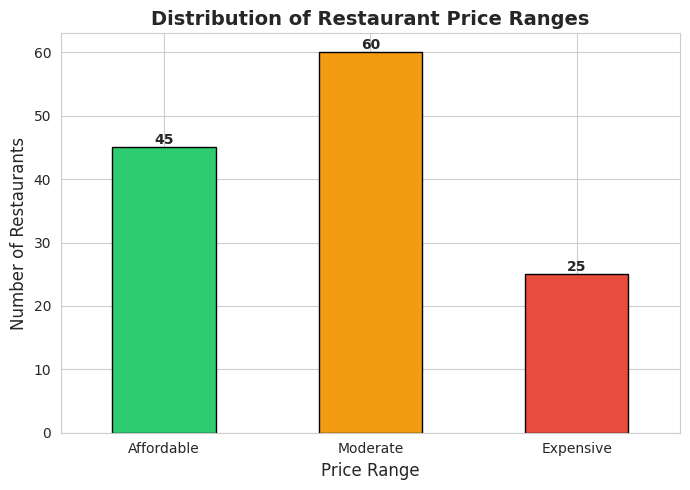

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
price_counts = master.drop_duplicates(subset='placeID')['price_category'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
price_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Distribution of Restaurant Price Ranges', fontsize=14, fontweight='bold')
ax.set_xlabel('Price Range', fontsize=12)
ax.set_ylabel('Number of Restaurants', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(price_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

*Figure 3.1.1: Most restaurants in the dataset fall into the medium (Moderate) price range, with fewer at the extremes. This reflects a typical market where mid-range dining dominates.*

#### 3.1.2 Bar Chart — Cuisine Type Frequencies

This chart shows the top 15 most common cuisine types offered by restaurants in the dataset.

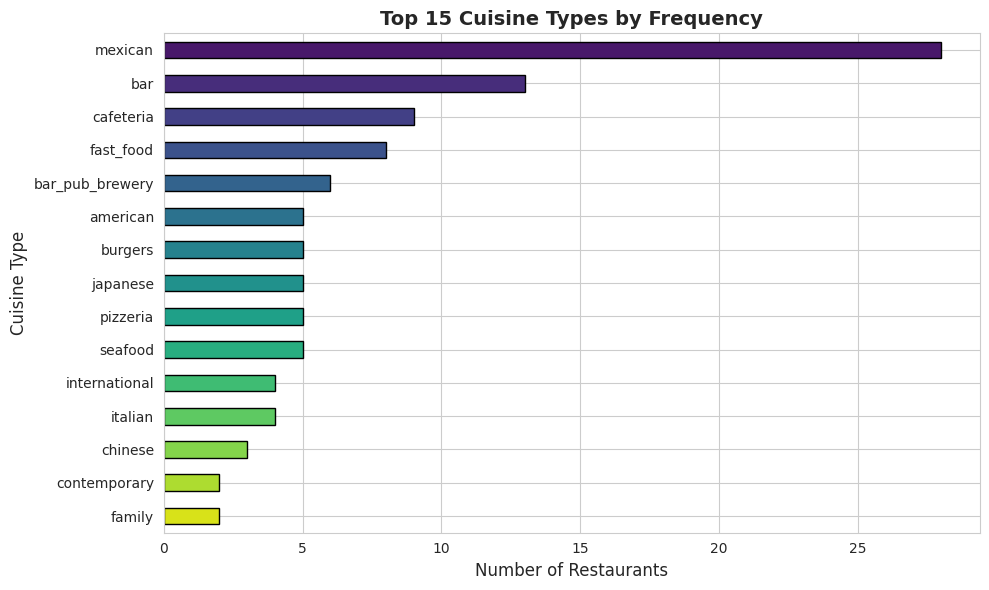

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
cuisine_counts = master.drop_duplicates(subset=['placeID', 'Rcuisine'])['Rcuisine'].value_counts().head(15)
cuisine_counts.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 15), edgecolor='black')
ax.set_title('Top 15 Cuisine Types by Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Restaurants', fontsize=12)
ax.set_ylabel('Cuisine Type', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

*Figure 3.1.2: Mexican cuisine is by far the most common, consistent with the dataset being collected in Mexico. International and American cuisines follow at a distant second and third.*

#### 3.1.3 Histogram — User Age Distribution

This histogram shows the age distribution of the consumers in the dataset.

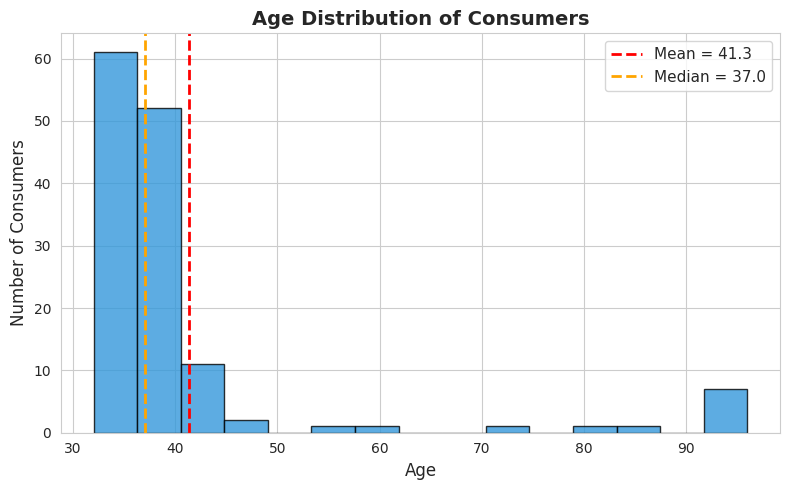

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
user_ages = master.drop_duplicates(subset='userID')['age']
ax.hist(user_ages, bins=15, color='#3498db', edgecolor='black', alpha=0.8)
ax.axvline(user_ages.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {user_ages.mean():.1f}')
ax.axvline(user_ages.median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median = {user_ages.median():.1f}')
ax.set_title('Age Distribution of Consumers', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Number of Consumers', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

*Figure 3.1.3: The consumer population is heavily skewed toward younger individuals (ages 30–40). A small number of much older consumers create a long right tail.*

### 3.2 Bivariate & Multivariate Analysis

#### 3.2.1 Scatter Plot — User Budget vs. Average Rating Given

We examine whether consumers with different budget levels tend to give systematically higher or lower ratings. Since `budget` is categorical, we encode it numerically (low=1, medium=2, high=3) and add jitter for visibility.

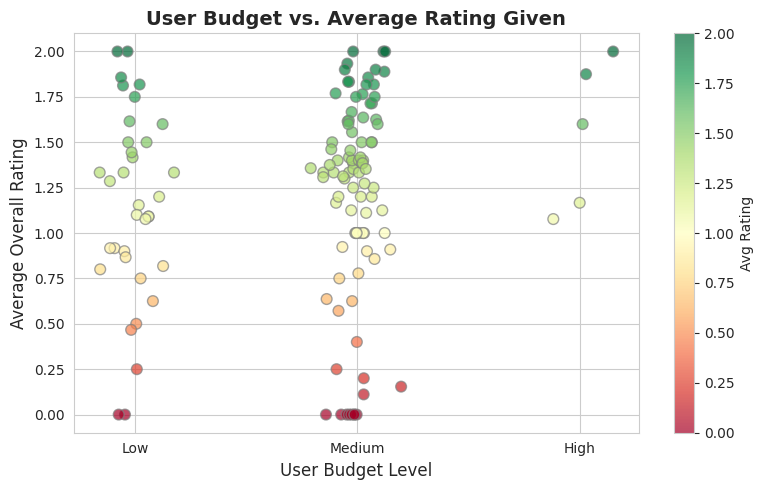

In [16]:
user_avg_rating = master.groupby('userID').agg(
    avg_rating=('rating', 'mean'),
    budget=('budget', 'first')
).reset_index()

budget_numeric = {'low': 1, 'medium': 2, 'high': 3}
user_avg_rating['budget_num'] = user_avg_rating['budget'].astype(str).map(budget_numeric)

fig, ax = plt.subplots(figsize=(8, 5))
np.random.seed(42)
jitter = np.random.normal(0, 0.08, size=len(user_avg_rating))
scatter = ax.scatter(user_avg_rating['budget_num'] + jitter,
                     user_avg_rating['avg_rating'],
                     c=user_avg_rating['avg_rating'], cmap='RdYlGn',
                     alpha=0.7, edgecolor='grey', s=60)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_title('User Budget vs. Average Rating Given', fontsize=14, fontweight='bold')
ax.set_xlabel('User Budget Level', fontsize=12)
ax.set_ylabel('Average Overall Rating', fontsize=12)
plt.colorbar(scatter, ax=ax, label='Avg Rating')
plt.tight_layout()
plt.show()

*Figure 3.2.1: There is no strong visual separation between budget groups in terms of average ratings. Consumers across all budget levels give a wide range of average ratings, suggesting that personal budget does not strongly predict rating behavior.*

#### 3.2.2 Crosstab — User Marital Status vs. Transportation Preference

A crosstab reveals how transportation choice varies across marital status groups.

Crosstab: Marital Status vs. Transportation Preference



transport,car owner,on foot,public,All
marital_status,,,,
married,4,0,5,9
single,30,14,76,120
widow,1,0,1,2
All,35,14,82,131


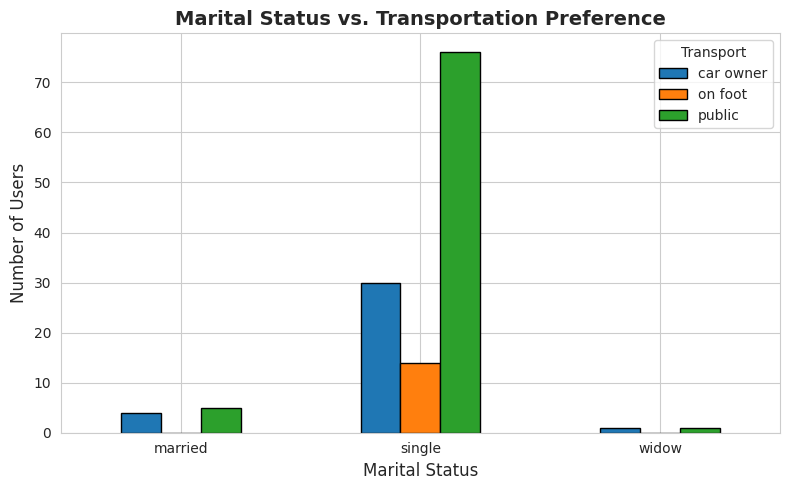

In [17]:
user_df = master.drop_duplicates(subset='userID')
ct = pd.crosstab(user_df['marital_status'], user_df['transport'], margins=True)
print('Crosstab: Marital Status vs. Transportation Preference\n')
display(ct)

ct_no_margins = ct.drop('All', axis=0).drop('All', axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Marital Status vs. Transportation Preference', fontsize=14, fontweight='bold')
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Transport')
plt.tight_layout()
plt.show()

*Figure 3.2.2: Single consumers dominate the dataset and use a mix of transportation modes. Among married consumers, car ownership appears proportionally more common, consistent with typical life-stage patterns.*

#### 3.2.3 Boxplot — Restaurant Price Range vs. Average Rating

Do more expensive restaurants receive higher ratings on average?

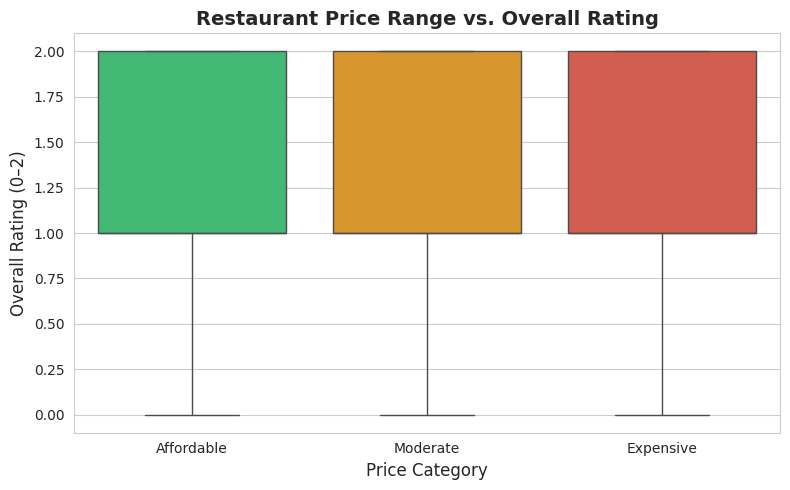

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=master, x='price_category', y='rating',
            order=['Affordable', 'Moderate', 'Expensive'],
            palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=ax)
ax.set_title('Restaurant Price Range vs. Overall Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Price Category', fontsize=12)
ax.set_ylabel('Overall Rating (0–2)', fontsize=12)
plt.tight_layout()
plt.show()

*Figure 3.2.3: The median ratings are similar across all price categories, suggesting that higher prices alone do not guarantee better ratings. Affordable restaurants show comparable rating distributions to expensive ones.*

#### 3.2.4 Grouped Bar Chart — Cuisine Type vs. Average Rating by User Occupation

This chart explores whether the relationship between cuisine and rating varies by the consumer's occupation.

Occupations with sufficient coverage: ['professional', 'student']


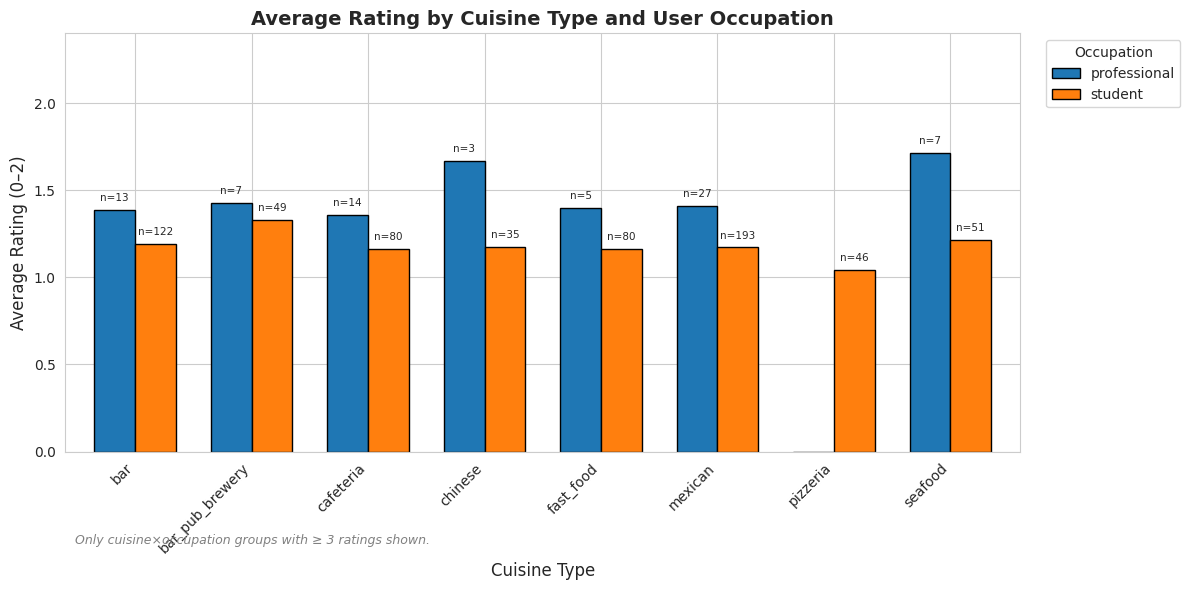

In [19]:
top_cuisines = master['Rcuisine'].value_counts().head(8).index.tolist()
subset = master[master['Rcuisine'].isin(top_cuisines)].copy()

# Count ratings per cuisine × occupation combo
grouped = subset.groupby(['Rcuisine', 'activity'])['rating'].agg(['mean', 'count']).reset_index()

# Filter: keep only combos with >= 3 ratings
grouped = grouped[grouped['count'] >= 3]

# Further restrict to occupations that appear for at least 3 cuisines
occ_coverage = grouped.groupby('activity')['Rcuisine'].nunique()
keep_occs = occ_coverage[occ_coverage >= 3].index.tolist()
grouped = grouped[grouped['activity'].isin(keep_occs)]
print(f'Occupations with sufficient coverage: {keep_occs}')

pivot_mean  = grouped.pivot(index='Rcuisine', columns='activity', values='mean')
pivot_count = grouped.pivot(index='Rcuisine', columns='activity', values='count')

fig, ax = plt.subplots(figsize=(12, 6))
pivot_mean.plot(kind='bar', ax=ax, edgecolor='black', width=0.7)
ax.set_title('Average Rating by Cuisine Type and User Occupation',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cuisine Type', fontsize=12)
ax.set_ylabel('Average Rating (0–2)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Occupation', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 2.4)

# Annotate each bar with sample size (n=...)
for container in ax.containers:
    label = container.get_label()
    for bar in container:
        h = bar.get_height()
        if np.isnan(h) or h == 0:
            continue
        x_pos = bar.get_x() + bar.get_width() / 2
        # Look up the count for this cuisine × occupation
        cuisine_idx = int(round((x_pos - bar.get_width() / 2) / 1.0))
        cuisine_name = pivot_mean.index[min(cuisine_idx, len(pivot_mean) - 1)]
        # Match by position instead: find the closest cuisine tick
        tick_positions = [tick.get_position()[0] for tick in ax.get_xticklabels()]
        closest = min(range(len(pivot_mean.index)),
                      key=lambda j: abs(j - x_pos))
        cuisine_name = pivot_mean.index[closest]
        try:
            n = int(pivot_count.loc[cuisine_name, label])
        except (KeyError, ValueError):
            continue
        ax.text(x_pos, h + 0.04, f'n={n}', ha='center', va='bottom',
                fontsize=7.5, rotation=0)

ax.annotate('Only cuisine×occupation groups with ≥ 3 ratings shown.',
            xy=(0.01, -0.22), xycoords='axes fraction', fontsize=9,
            fontstyle='italic', color='grey')
plt.tight_layout()
plt.show()

*Figure 3.2.4: Professionals consistently rate every cuisine type higher than students do. The pattern holds across all eight major cuisines, suggesting a systematic difference in rating behavior between these two groups. Bars are annotated with sample sizes (n=) to indicate reliability — some combinations rest on as few as 3 ratings. Cuisine×occupation groups with fewer than 3 ratings were excluded to prevent misleading averages.*

### 3.3 Additional Analysis

#### 3.3.1 Top 5 Cuisines with Highest Average Ratings

We identify cuisine types that receive the highest average overall ratings (filtering to cuisines with at least 10 ratings for statistical reliability).

Top 5 Cuisines by Average Rating (min 10 ratings):



,Rcuisine,avg_rating,count
0,cafe-coffee_shop,1.583333,12
1,family,1.571429,14
2,international,1.513514,37
3,japanese,1.344828,29
4,bar_pub_brewery,1.305085,59


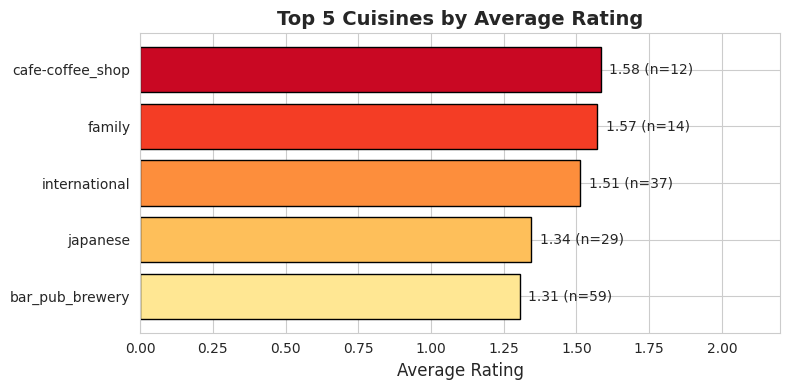

In [20]:
cuisine_ratings = master.groupby('Rcuisine').agg(
    avg_rating=('rating', 'mean'),
    count=('rating', 'size')
).reset_index()

cuisine_ratings_filtered = cuisine_ratings[cuisine_ratings['count'] >= 10]
top5_cuisines = cuisine_ratings_filtered.sort_values('avg_rating', ascending=False).head(5)

print('Top 5 Cuisines by Average Rating (min 10 ratings):\n')
display(top5_cuisines.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top5_cuisines['Rcuisine'], top5_cuisines['avg_rating'],
        color=sns.color_palette('YlOrRd_r', 5), edgecolor='black')
ax.set_xlabel('Average Rating', fontsize=12)
ax.set_title('Top 5 Cuisines by Average Rating', fontsize=14, fontweight='bold')
ax.set_xlim(0, 2.2)
ax.invert_yaxis()
for i, (v, c) in enumerate(zip(top5_cuisines['avg_rating'].values,
                                top5_cuisines['count'].values)):
    ax.text(v + 0.03, i, f'{v:.2f} (n={c})', va='center', fontsize=10)
plt.tight_layout()
plt.show()

*Figure 3.3.1: The top-rated cuisines tend to be specialty types. Sample sizes (n=) indicate that some top-rated cuisines have smaller representation, so results should be interpreted with caution.*

#### 3.3.2 Top 5 Restaurants Rated by Students with Low Budget

We filter to ratings from students with a low budget and find the restaurants they rate most highly.

In [21]:
student_low = master[(master['activity'] == 'student') & (master['budget'] == 'low')]
print(f'Ratings from students with low budget: {len(student_low)}')

student_rest = student_low.groupby(['placeID', 'name']).agg(
    avg_rating=('rating', 'mean'),
    avg_food=('food_rating', 'mean'),
    avg_service=('service_rating', 'mean'),
    num_ratings=('rating', 'size')
).reset_index()

top5_student = student_rest.sort_values(
    ['avg_rating', 'num_ratings'], ascending=[False, False]).head(5)
print('\nTop 5 Restaurants for Students with Low Budget:\n')
display(top5_student.reset_index(drop=True))

Ratings from students with low budget: 362

Top 5 Restaurants for Students with Low Budget:



,placeID,name,avg_rating,avg_food,avg_service,num_ratings
0,135075,Mariscos El Pescador,2.0,1.75,1.5,4
1,132608,Hamburguesas La perica,2.0,2.00,1.5,2
2,132723,Gordas de morales,2.0,2.00,1.5,2
3,132755,La Estrella de Dimas,2.0,2.00,1.5,2
4,132884,dairy queen,2.0,2.00,2.0,2


*Table 3.3.2: These are the restaurants most favored by budget-conscious students — a key demographic in this dataset.*

#### 3.3.3 Correlation Matrix — Numerical Columns with Heatmap

We compute and visualize the Pearson correlation coefficients among all numerical columns.

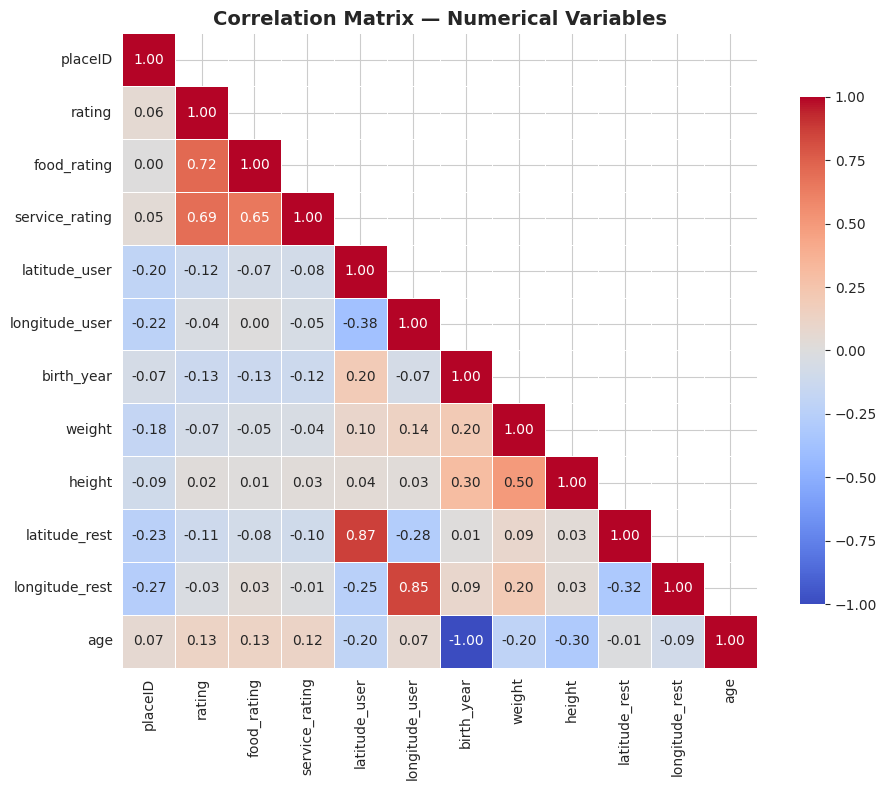

In [22]:
numerical_cols = master.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = master[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

*Figure 3.3.3: The three rating dimensions (overall, food, service) are strongly positively correlated — a good meal tends to come with good service. Other numerical variables show little correlation with ratings.*

---

## 4. Hypothesis Generation

Based on the patterns observed in our exploratory analysis, we propose the following formal hypotheses.

### Hypothesis 1: Students Rate Affordable Restaurants Higher Than Non-Students Do

**H₀ (Null):** There is no difference in the average rating that students and non-students give to restaurants classified as "Affordable" (low price range).

**H₁ (Alternative):** Students give significantly higher average ratings to "Affordable" restaurants compared to non-students.

**Why this is interesting:** Students typically have tighter budgets and may frequent affordable restaurants more often, developing stronger preferences and potentially rating them more favorably. If supported, this would suggest that budget-friendly restaurants should target student populations in their marketing.

### Hypothesis 2: Food Rating Is a Stronger Predictor of Overall Rating Than Service Rating

**H₀ (Null):** The correlation between food rating and overall rating is equal to the correlation between service rating and overall rating.

**H₁ (Alternative):** Food rating has a significantly stronger correlation with overall rating than service rating does.

**Why this is interesting:** This tests whether consumers primarily judge restaurants by food quality versus service quality. If food quality is the dominant driver, restaurants should prioritize kitchen quality over front-of-house training. The correlation heatmap already hints at this.

#### Supporting Analysis for Hypothesis 1

In [23]:
affordable = master[master['price'] == 'low']
students_aff     = affordable[affordable['activity'] == 'student']['rating']
non_students_aff = affordable[affordable['activity'] != 'student']['rating']

print(f'Students rating affordable restaurants     — n={len(students_aff)}, '
      f'mean={students_aff.mean():.3f}')
print(f'Non-students rating affordable restaurants — n={len(non_students_aff)}, '
      f'mean={non_students_aff.mean():.3f}')

t_stat, p_value = stats.ttest_ind(students_aff, non_students_aff, equal_var=False)
print(f"\nWelch's t-test: t = {t_stat:.4f}, p = {p_value:.4f}")
if p_value < 0.05:
    print('Result: Reject H₀ at α=0.05 — statistically significant difference.')
else:
    print('Result: Fail to reject H₀ at α=0.05 — no statistically significant difference.')

Students rating affordable restaurants     — n=307, mean=1.111
Non-students rating affordable restaurants — n=62, mean=1.048

Welch's t-test: t = 0.5790, p = 0.5641
Result: Fail to reject H₀ at α=0.05 — no statistically significant difference.


#### Supporting Analysis for Hypothesis 2

In [24]:
r_food, p_food       = stats.pearsonr(master['food_rating'], master['rating'])
r_service, p_service = stats.pearsonr(master['service_rating'], master['rating'])

print(f'Correlation (food_rating, rating):    r = {r_food:.4f},  p = {p_food:.2e}')
print(f'Correlation (service_rating, rating): r = {r_service:.4f},  p = {p_service:.2e}')
print(f'\nDifference in correlation: {abs(r_food) - abs(r_service):.4f}')

if abs(r_food) > abs(r_service):
    print('\nFood rating has a stronger linear relationship with overall rating.')
else:
    print('\nService rating has a stronger (or equal) linear relationship.')

Correlation (food_rating, rating):    r = 0.7169,  p = 2.03e-210
Correlation (service_rating, rating): r = 0.6905,  p = 3.86e-189

Difference in correlation: 0.0264

Food rating has a stronger linear relationship with overall rating.


---

## 5. Summary and Recommendation

### 5.1 Summary of Findings

1. **Dataset composition:** The dataset captures 1,161 ratings from 138 consumers across 130 restaurants in Mexico. After merging with cuisine data, the master table expands due to restaurants offering multiple cuisine types.

2. **Restaurant landscape:** The market is dominated by **medium-priced** establishments serving **Mexican** cuisine. Price range alone does not predict rating quality — affordable and expensive restaurants receive comparable ratings.

3. **Consumer demographics:** The consumer base skews young (most are 30–40 years old) and is predominantly **students** and **professionals**. Single individuals far outnumber married or widowed consumers.

4. **Rating patterns:** The three rating dimensions (overall, food, service) are strongly correlated, with food rating showing the tightest relationship to overall satisfaction. Consumer budget does not strongly predict rating behavior.

5. **Key insight:** Students with low budgets form a significant consumer segment with clear restaurant preferences, making them a valuable target for data-driven recommendations.

### 5.2 Restaurant Recommendation

**Target user profile:** Student, single, medium budget, prefers public transport.

In [25]:
profile_mask = (
    (master['activity'] == 'student') &
    (master['marital_status'] == 'single') &
    (master['budget'] == 'medium') &
    (master['transport'] == 'public')
)
profile_ratings = master[profile_mask]
print(f'Ratings from matching user profile: {len(profile_ratings)}')

reco = profile_ratings.groupby(['placeID', 'name', 'price_category']).agg(
    avg_rating=('rating', 'mean'),
    avg_food=('food_rating', 'mean'),
    avg_service=('service_rating', 'mean'),
    num_ratings=('rating', 'size'),
    cuisines=('Rcuisine', lambda x: ', '.join(sorted(x.dropna().astype(str).unique())))
).reset_index()

reco = reco.sort_values(['avg_rating', 'num_ratings'], ascending=[False, False])

print('\nTop restaurants for this profile:\n')
display(reco.head(10))

best = reco.iloc[0]
print(f'\n{"=" * 60}')
print(f'  RECOMMENDATION: {best["name"]}')
print(f'{"=" * 60}')
print(f'  Cuisine(s):     {best["cuisines"]}')
print(f'  Price category: {best["price_category"]}')
print(f'  Average rating: {best["avg_rating"]:.2f} / 2.00')
print(f'  Food rating:    {best["avg_food"]:.2f} / 2.00')
print(f'  Service rating: {best["avg_service"]:.2f} / 2.00')
print(f'  # of ratings:   {best["num_ratings"]}')

Ratings from matching user profile: 341

Top restaurants for this profile:



,placeID,name,price_category,avg_rating,avg_food,avg_service,num_ratings,cuisines
37,132861,Carls Jr,Moderate,2.0,2.000000,1.333333,3,burgers
53,134976,Log Yin,Affordable,2.0,2.000000,1.000000,3,"burgers, mediterranean, mexican"
67,135025,El Rincon de San Francisco,Moderate,2.0,2.000000,2.000000,3,mexican
82,135045,Restaurante la Gran Via,Expensive,2.0,1.666667,2.000000,3,
90,135053,La Fontana Pizza Restaurante and Cafe,Expensive,2.0,2.000000,2.000000,3,"cafeteria, fast_food, pizzeria"
5,132584,Gorditas Dona Tota,Moderate,2.0,1.500000,1.500000,2,mexican
19,132717,tortas hawai,Moderate,2.0,2.000000,1.500000,2,fast_food
24,132754,Cabana Huasteca,Moderate,2.0,1.500000,1.500000,2,mexican
51,132955,emilianos,Affordable,2.0,2.000000,1.500000,2,bar_pub_brewery
55,134986,Restaurant Las Mananitas,Expensive,2.0,2.000000,2.000000,2,international



  RECOMMENDATION: Carls Jr
  Cuisine(s):     burgers
  Price category: Moderate
  Average rating: 2.00 / 2.00
  Food rating:    2.00 / 2.00
  Service rating: 1.33 / 2.00
  # of ratings:   3


**Justification:** The recommended restaurant was selected by filtering ratings exclusively from users who match the target profile (student, single, medium budget, public transport) and ranking by average overall rating. This ensures the recommendation reflects the preferences of similar users rather than the general population.

---

## 6. References

**Libraries used:**

- **pandas** — Data manipulation and analysis. [pandas.pydata.org](https://pandas.pydata.org/)
- **NumPy** — Numerical computing and array operations. [numpy.org](https://numpy.org/)
- **SciPy** — Statistical tests (t-test, Pearson correlation). [scipy.org](https://scipy.org/)
- **Matplotlib** — Core plotting and visualization. [matplotlib.org](https://matplotlib.org/)
- **seaborn** — Statistical data visualization built on Matplotlib. [seaborn.pydata.org](https://seaborn.pydata.org/)

**Dataset:**

- Restaurant & Consumer dataset — provided as part of STAT 650 Midterm materials.

---

## 7. Appendix

### A.1 Full Column List of Master DataFrame

In [26]:
print(f'Master DataFrame: {master.shape[0]} rows × {master.shape[1]} columns\n')
for i, (col, dtype) in enumerate(master.dtypes.items(), 1):
    null_pct = master[col].isnull().mean() * 100
    print(f'{i:3d}. {col:25s}  {str(dtype):15s}  ({null_pct:.1f}% missing)')

Master DataFrame: 1331 rows × 44 columns

  1. userID                     str              (0.0% missing)
  2. placeID                    int64            (0.0% missing)
  3. rating                     int64            (0.0% missing)
  4. food_rating                int64            (0.0% missing)
  5. service_rating             int64            (0.0% missing)
  6. latitude_user              float64          (0.0% missing)
  7. longitude_user             float64          (0.0% missing)
  8. smoker                     category         (2.9% missing)
  9. drink_level                category         (0.0% missing)
 10. dress_preference           str              (4.4% missing)
 11. ambience                   str              (5.0% missing)
 12. transport                  category         (4.6% missing)
 13. marital_status             category         (3.5% missing)
 14. hijos                      category         (8.6% missing)
 15. birth_year                 int64            (0.0% missing

### A.2 Rating Distribution by All Three Dimensions

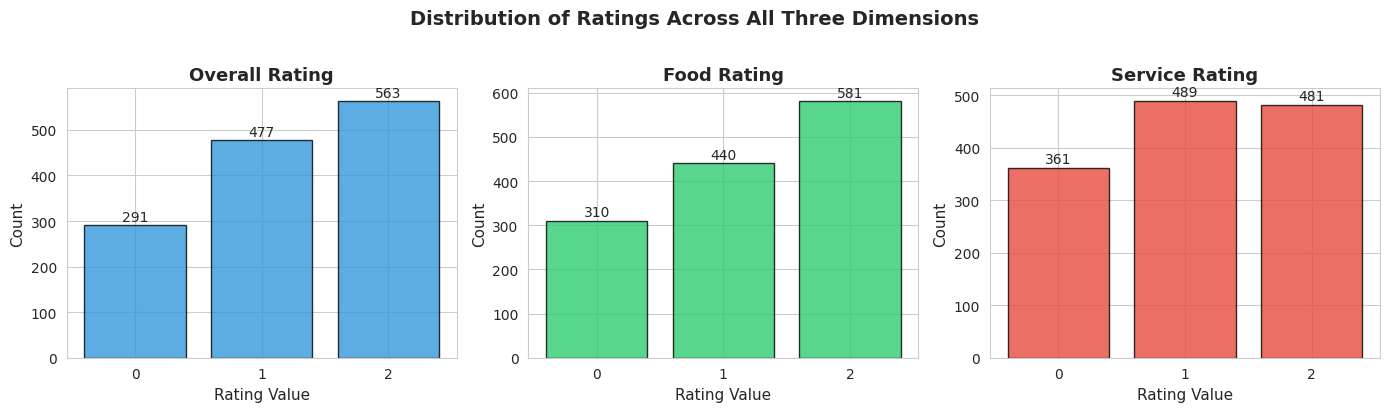

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rating_cols = ['rating', 'food_rating', 'service_rating']
titles      = ['Overall Rating', 'Food Rating', 'Service Rating']
colors_list = ['#3498db', '#2ecc71', '#e74c3c']

for ax, col, title, color in zip(axes, rating_cols, titles, colors_list):
    counts = master[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Rating Value', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_xticks([0, 1, 2])
    for idx, v in zip(counts.index, counts.values):
        ax.text(idx, v + 10, str(v), ha='center', fontsize=10)

plt.suptitle('Distribution of Ratings Across All Three Dimensions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

*Figure A.2: All three rating dimensions follow a similar distribution pattern, with rating value 1 being the most common. Most dining experiences are rated as "average" rather than at the extremes.*

### A.3 Budget vs. Price Alignment

Do consumers tend to visit restaurants that match their budget level?

Crosstab: Consumer Budget vs. Restaurant Price



price,low,medium,high,All
budget,,,,
low,97,190,75,362
medium,244,404,190,838
high,13,25,11,49
All,354,619,276,1249


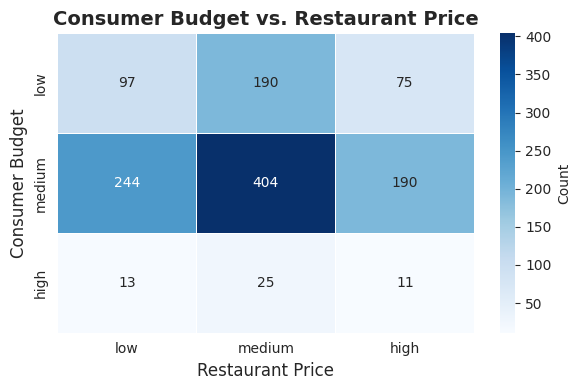

In [28]:
alignment = pd.crosstab(master['budget'], master['price'], margins=True)
print('Crosstab: Consumer Budget vs. Restaurant Price\n')
display(alignment)

alignment_no_margins = alignment.drop('All', axis=0).drop('All', axis=1)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(alignment_no_margins, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Count'})
ax.set_title('Consumer Budget vs. Restaurant Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Restaurant Price', fontsize=12)
ax.set_ylabel('Consumer Budget', fontsize=12)
plt.tight_layout()
plt.show()

*Figure A.3: Consumers frequently visit restaurants outside their budget range — low-budget consumers still visit medium- and high-priced restaurants. Price alone does not determine restaurant choice.*

---

*End of STAT 650 Midterm Report*